imports and setup

In [9]:
import json, random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from tqdm import tqdm
from ultralytics import YOLO
import yaml
import torch
%matplotlib inline

ROOT_DIR = Path(".").resolve()
NUMDET_DIR = ROOT_DIR / "numberdetection.v2i.yolov11"
SVHN_DIR = ROOT_DIR / "svhn.v1i.yolov11"
IMAGES_DIR = ROOT_DIR / "images"
OUT_DIR = ROOT_DIR / "output"
OUT_DIR.mkdir(exist_ok=True)

NUMDET_CLASSES = [str(i) for i in range(10)]
SVHN_CLASSES = ['1', '10', '2', '3', '4', '5', '6', '7', '8', '9']

def get_device():
    if torch.cuda.is_available():
        return "0"
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return "mps"
    return "cpu"

DEVICE = get_device()
print(f"device: {DEVICE}")

device: mps


dataset yaml files — absolute paths for ultralytics

In [10]:
def write_yaml(path, content):
    Path(path).write_text(yaml.dump(content, default_flow_style=False, allow_unicode=True))
    print(f"wrote {path}")

NUMDET_YAML = OUT_DIR / "numdet.yaml"
write_yaml(NUMDET_YAML, {
    "path": str(NUMDET_DIR), "train": "train/images", "val": "valid/images",
    "nc": 10, "names": NUMDET_CLASSES,
})

SVHN_YAML = OUT_DIR / "svhn.yaml"
write_yaml(SVHN_YAML, {
    "path": str(SVHN_DIR), "train": "train/images", "val": "valid/images",
    "test": "test/images", "nc": 10, "names": SVHN_CLASSES,
})

print(f"numdet  train={len(list((NUMDET_DIR/'train'/'images').glob('*')))}  valid={len(list((NUMDET_DIR/'valid'/'images').glob('*')))}")
print(f"svhn    train={len(list((SVHN_DIR/'train'/'images').glob('*')))}  valid={len(list((SVHN_DIR/'valid'/'images').glob('*')))}  test={len(list((SVHN_DIR/'test'/'images').glob('*')))}")

wrote /Users/zji25/PycharmProjects/comp-vision/lab2/output/numdet.yaml
wrote /Users/zji25/PycharmProjects/comp-vision/lab2/output/svhn.yaml
numdet  train=1032  valid=99
svhn    train=21093  valid=858  test=641


visualize numberdetection and svhn dataset samples

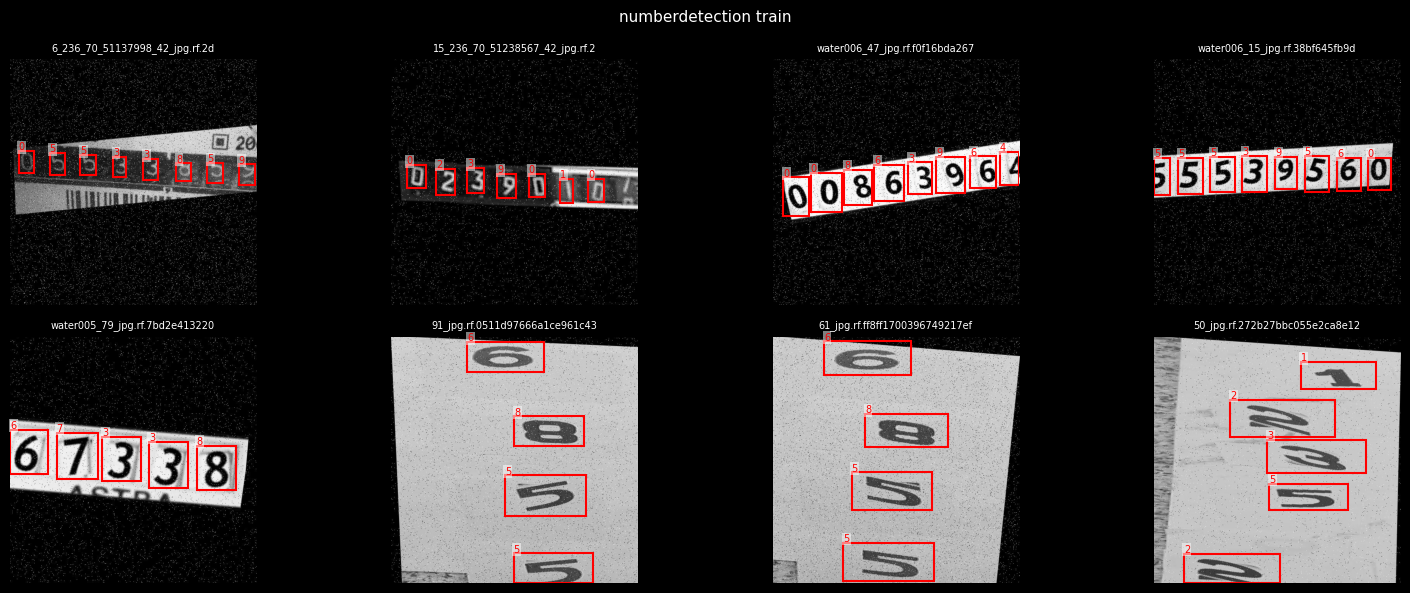

  -> /Users/zji25/PycharmProjects/comp-vision/lab2/output/samples_numberdetection_train.png


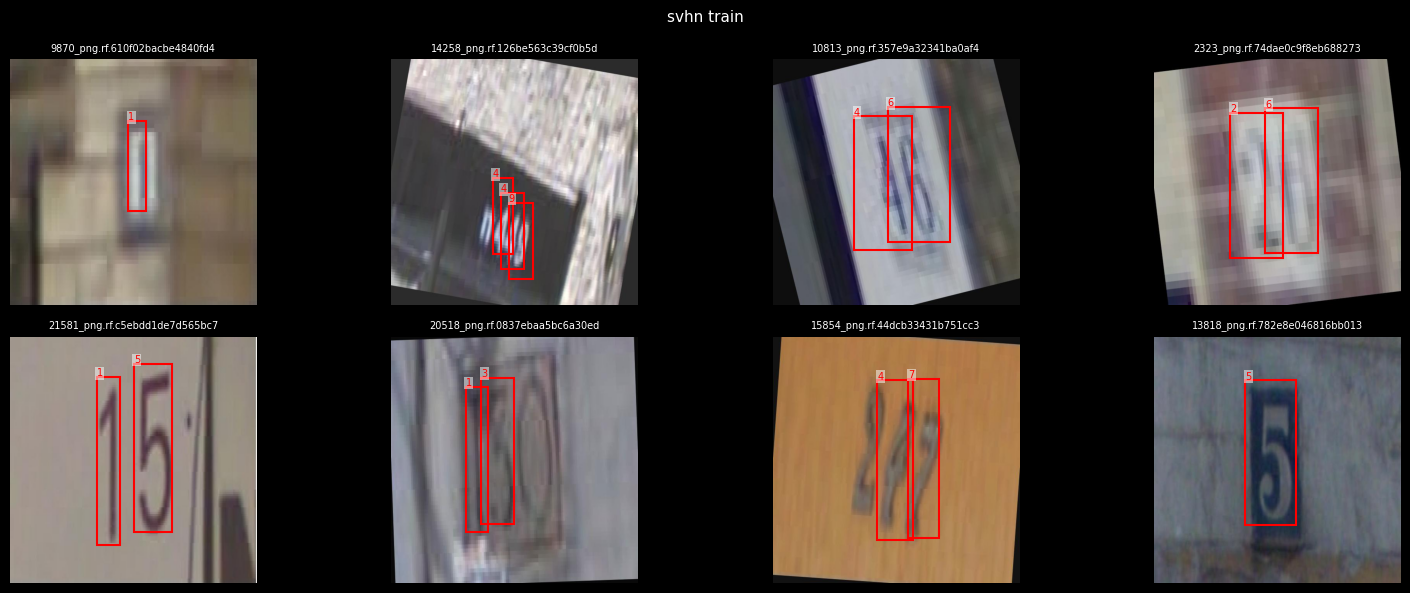

  -> /Users/zji25/PycharmProjects/comp-vision/lab2/output/samples_svhn_train.png


In [11]:
def show_yolo_samples(images_dir, labels_dir, class_names, n=8, seed=42, title=""):
    image_paths = sorted(list(Path(images_dir).glob("*.jpg")) + list(Path(images_dir).glob("*.jpeg")))
    rng = random.Random(seed)
    sample = rng.sample(image_paths, min(n, len(image_paths)))
    cols = min(n, 4)
    rows = (len(sample) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3))
    axes = np.array(axes).flatten()
    for ax, img_path in zip(axes, sample):
        img = Image.open(img_path).convert("RGB")
        w, h = img.size
        ax.imshow(img)
        lbl = Path(labels_dir) / (img_path.stem + ".txt")
        if lbl.exists():
            for line in lbl.read_text().strip().splitlines():
                parts = line.split()
                if len(parts) < 5:
                    continue
                cls_idx = int(parts[0])
                cx, cy, bw, bh = map(float, parts[1:5])
                x1 = (cx - bw / 2) * w
                y1 = (cy - bh / 2) * h
                label = class_names[cls_idx] if cls_idx < len(class_names) else str(cls_idx)
                rect = patches.Rectangle((x1, y1), bw * w, bh * h, linewidth=1.5, edgecolor="red", facecolor="none")
                ax.add_patch(rect)
                ax.text(x1, y1 - 2, label, color="red", fontsize=7, bbox=dict(facecolor="white", alpha=0.5, pad=1, edgecolor="none"))
        ax.axis("off")
        ax.set_title(img_path.name[:30], fontsize=7)
    for ax in axes[len(sample):]:
        ax.axis("off")
    fig.suptitle(title, fontsize=11)
    fig.tight_layout()
    out = OUT_DIR / f"samples_{title.replace(' ', '_')}.png"
    fig.savefig(out, dpi=110)
    plt.show()
    print(f"  -> {out}")

show_yolo_samples(
    NUMDET_DIR / "train" / "images",
    NUMDET_DIR / "train" / "labels",
    NUMDET_CLASSES, n=8, title="numberdetection train"
)
show_yolo_samples(
    SVHN_DIR / "train" / "images",
    SVHN_DIR / "train" / "labels",
    SVHN_CLASSES, n=8, title="svhn train"
)

training helper — load-or-train yolov11

In [12]:
def load_or_train(data_yaml, run_name, base_weights="yolo11n.pt", epochs=50, imgsz=640, batch=16, **extra):
    import shutil, pandas as pd
    project = str(OUT_DIR / "runs")
    run_dir = Path(project) / run_name
    best_pt = run_dir / "weights" / "best.pt"
    last_pt = run_dir / "weights" / "last.pt"
    csv_path = run_dir / "results.csv"
    train_kwargs = dict(
        data=str(data_yaml), imgsz=imgsz, batch=batch,
        device=DEVICE, project=project, name=run_name, exist_ok=True, verbose=True,
        workers=0 if DEVICE == "mps" else 8,
        **extra,
    )
    completed = 0
    if csv_path.exists():
        try:
            completed = len(pd.read_csv(csv_path))
        except Exception:
            pass

    # best.pt is only written when training finishes a full epoch — if it exists and
    # either the CSV confirms completion or the CSV is simply missing, treat as done.
    if best_pt.exists() and (not csv_path.exists() or completed >= epochs):
        print(f"done ({completed}/{epochs} epochs), loading {best_pt.name}")
        return YOLO(str(best_pt))

    if last_pt.exists() and completed > 0:
        remaining = epochs - completed
        print(f"continuing from epoch {completed}/{epochs} ({remaining} remaining)")
        model = YOLO(str(last_pt))
        model.train(epochs=remaining, **train_kwargs)
        return YOLO(str(best_pt))

    weights_name = Path(base_weights).name
    out_weights = OUT_DIR / weights_name
    resolved = str(out_weights) if out_weights.exists() else base_weights
    model = YOLO(resolved)

    cwd_weights = Path(weights_name)
    if cwd_weights.exists() and cwd_weights.resolve() != out_weights.resolve():
        shutil.move(str(cwd_weights), str(out_weights))
        print(f"moved {cwd_weights} -> {out_weights}")

    model.train(epochs=epochs, **train_kwargs)
    return YOLO(str(best_pt))

evaluation helpers — iou, precision, recall, map

In [13]:
def compute_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    inter = max(0.0, x2 - x1) * max(0.0, y2 - y1)
    a1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    a2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = a1 + a2 - inter
    return inter / union if union > 0 else 0.0

def compute_mean_iou(model, images_dir, labels_dir, conf=0.25, iou_thresh=0.5, n_max=None):
    image_paths = sorted(list(Path(images_dir).glob("*.jpg")) + list(Path(images_dir).glob("*.jpeg")))
    if n_max:
        image_paths = image_paths[:n_max]
    all_ious, tp, fp, fn = [], 0, 0, 0
    for img_path in tqdm(image_paths, desc="computing iou"):
        lbl_path = Path(labels_dir) / (img_path.stem + ".txt")
        if not lbl_path.exists():
            continue
        img = Image.open(img_path)
        w, h = img.size
        gt_boxes = []
        for line in lbl_path.read_text().strip().splitlines():
            parts = line.split()
            if len(parts) < 5:
                continue
            cx, cy, bw, bh = map(float, parts[1:5])
            gt_boxes.append([(cx-bw/2)*w, (cy-bh/2)*h, (cx+bw/2)*w, (cy+bh/2)*h])
        result = model.predict(str(img_path), conf=conf, device=DEVICE, verbose=False)[0]
        if result.boxes is None or len(result.boxes) == 0:
            fn += len(gt_boxes)
            continue
        pred_xyxy = result.boxes.xyxy.cpu().numpy()
        matched_gt = set()
        for pb in pred_xyxy:
            best_iou, best_j = 0.0, -1
            for j, gb in enumerate(gt_boxes):
                if j in matched_gt:
                    continue
                iou = compute_iou(pb, gb)
                if iou > best_iou:
                    best_iou, best_j = iou, j
            if best_j >= 0 and best_iou >= iou_thresh:
                tp += 1
                matched_gt.add(best_j)
                all_ious.append(best_iou)
            else:
                fp += 1
        fn += len(gt_boxes) - len(matched_gt)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    mean_iou = float(np.mean(all_ious)) if all_ious else 0.0
    return {"mean_iou": mean_iou, "precision": precision, "recall": recall, "tp": tp, "fp": fp, "fn": fn}

def print_metrics(metrics, name):
    print(f"\n{'─'*45}\n  {name}\n{'─'*45}")
    for k, v in metrics.items():
        print(f"  {k:<20} {v:.4f}" if isinstance(v, float) else f"  {k:<20} {v}")
    print(f"{'─'*45}")

stage 1 — pre-train yolov11n on numberdetection (50 epochs)

In [14]:
model_numdet = load_or_train(data_yaml=NUMDET_YAML, run_name="numdet_yolo11n", base_weights="yolo11n.pt", epochs=50, imgsz=640, batch=16)

done (0/50 epochs), loading best.pt


stage 2 — fine-tune on svhn train (20 epochs, fraction=0.3, imgsz=416)

In [15]:
numdet_best = OUT_DIR / "runs" / "numdet_yolo11n" / "weights" / "best.pt"
model_final = load_or_train(data_yaml=SVHN_YAML, run_name="svhn_finetune", base_weights=str(numdet_best), epochs=20, imgsz=416, batch=16, fraction=0.3)

done (0/20 epochs), loading best.pt


evaluate on svhn test set — iou, precision, recall, map

In [16]:
SUMMARY_PATH = OUT_DIR / "summary.json"

if SUMMARY_PATH.exists():
    with open(SUMMARY_PATH) as f:
        _cached = json.load(f)
    map50    = _cached["mAP50"]
    map5095  = _cached["mAP50_95"]
    prec     = _cached["precision"]
    rec      = _cached["recall"]
    iou_metrics = {
        "mean_iou":  _cached["mean_iou"],
        "precision": _cached["precision_iou"],
        "recall":    _cached["recall_iou"],
        "tp": _cached.get("tp", 0),
        "fp": _cached.get("fp", 0),
        "fn": _cached.get("fn", 0),
    }
    print("loaded cached eval results from summary.json")
    print(f"mAP@50:    {map50:.4f}")
    print(f"mAP@50-95: {map5095:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"target mAP@50 >= 0.60: {'✓' if map50 >= 0.60 else '✗'}")
    print_metrics(iou_metrics, "iou / p / r  (svhn test, cached)")
else:
    val_metrics = model_final.val(data=str(SVHN_YAML), split="test", conf=0.25, iou=0.5, device=DEVICE, verbose=True)
    map50    = float(val_metrics.box.map50)
    map5095  = float(val_metrics.box.map)
    prec     = float(val_metrics.box.mp)
    rec      = float(val_metrics.box.mr)
    print(f"mAP@50:    {map50:.4f}")
    print(f"mAP@50-95: {map5095:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"target mAP@50 >= 0.60: {'✓' if map50 >= 0.60 else '✗'}")

    iou_metrics = compute_mean_iou(model_final, SVHN_DIR / "test" / "images", SVHN_DIR / "test" / "labels", conf=0.25, iou_thresh=0.5)
    print_metrics(iou_metrics, "iou / p / r  (svhn test)")

Ultralytics 8.4.37 🚀 Python-3.14.4 torch-2.10.0 MPS (Apple M2 Pro)
YOLO11n summary (fused): 101 layers, 2,584,102 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.3±0.3 ms, read: 76.3±32.1 MB/s, size: 20.3 KB)
val: Scanning /Users/zji25/PycharmProjects/comp-vision/lab2/svhn.v1i.yolov11/test/labels.cache... 641 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 641/641 298.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 41/41 2.9it/s 14.4s0.3s
                   all        641       1349      0.852      0.781       0.77      0.348
                     1        246        283      0.836       0.71      0.686      0.248
                    10         75         77       0.83      0.818      0.793      0.401
                     2        184        206      0.869      0.872      0.866      0.406
                     3        138        146      0.883      0.724      0.726       0.33
              

computing iou: 100%|██████████| 641/641 [00:11<00:00, 56.27it/s]


─────────────────────────────────────────────
  iou / p / r  (svhn test)
─────────────────────────────────────────────
  mean_iou             0.7312
  precision            0.8167
  recall               0.8325
  tp                   1123
  fp                   252
  fn                   226
─────────────────────────────────────────────


inference on photos

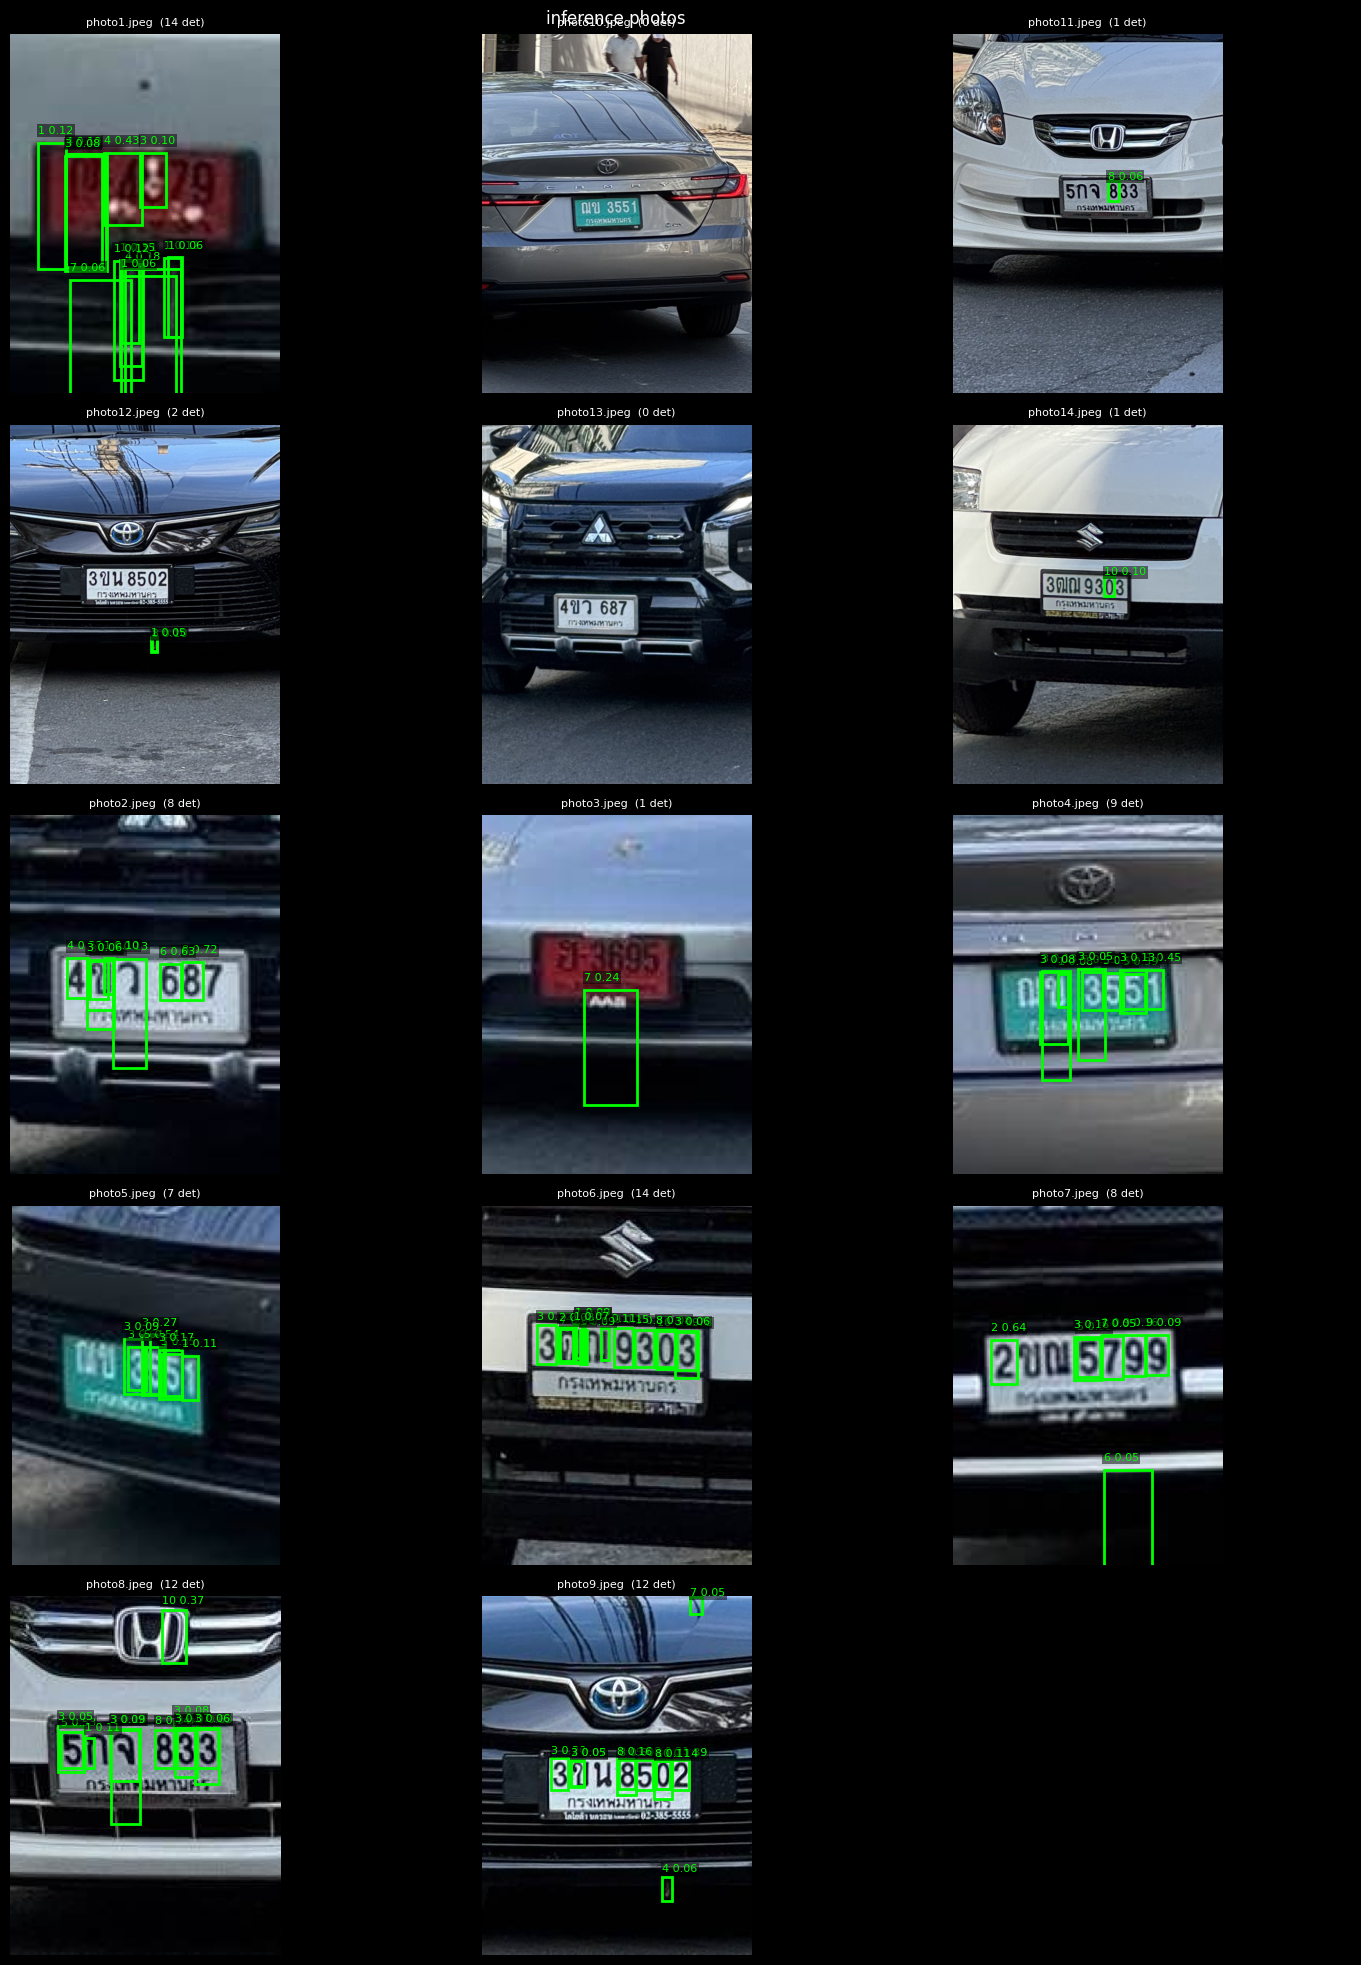

-> /Users/zji25/PycharmProjects/comp-vision/lab2/output/inference_photos.png


In [27]:
def show_inference(model, images_dir, class_names, conf=0.25, imgsz=1280, title="inference", n=None):
    img_paths = sorted(list(Path(images_dir).glob("*.jpg")) + list(Path(images_dir).glob("*.jpeg")))
    if not img_paths:
        print(f"no images in {images_dir}")
        return
    if n is not None and n < len(img_paths):
        img_paths = random.sample(img_paths, n)
    results = model.predict(img_paths, conf=conf, imgsz=imgsz, device=DEVICE, verbose=False)
    n_imgs = len(results)
    cols = min(n_imgs, 3)
    rows = (n_imgs + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
    axes = np.array(axes).flatten()
    for ax, (img_path, result) in zip(axes, zip(img_paths, results)):
        img = Image.open(img_path).convert("RGB")
        ax.imshow(img)
        if result.boxes is not None and len(result.boxes) > 0:
            for box in result.boxes:
                x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
                cls_id = int(box.cls[0].item())
                conf_v = float(box.conf[0].item())
                label = class_names[cls_id] if cls_id < len(class_names) else str(cls_id)
                ax.add_patch(patches.Rectangle(
                    (x1, y1), x2-x1, y2-y1, linewidth=2, edgecolor="lime", facecolor="none"
                ))
                ax.text(x1, max(y1-4, 0), f"{label} {conf_v:.2f}", color="lime", fontsize=8,
                        bbox=dict(facecolor="black", alpha=0.5, pad=1, edgecolor="none"))
        n_det = len(result.boxes) if result.boxes is not None else 0
        ax.set_title(f"{img_path.name[:20]}  ({n_det} det)", fontsize=8)
        ax.axis("off")
    for ax in axes[n_imgs:]:
        ax.axis("off")
    fig.suptitle(title, fontsize=12)
    fig.tight_layout()
    out = OUT_DIR / f"{title.replace(' ', '_')}.png"
    fig.savefig(out, dpi=110)
    plt.show()
    print(f"-> {out}")

show_inference(model_final,  IMAGES_DIR, SVHN_CLASSES, conf=0.05, imgsz=1280, title="inference photos")

inference on svhn test images

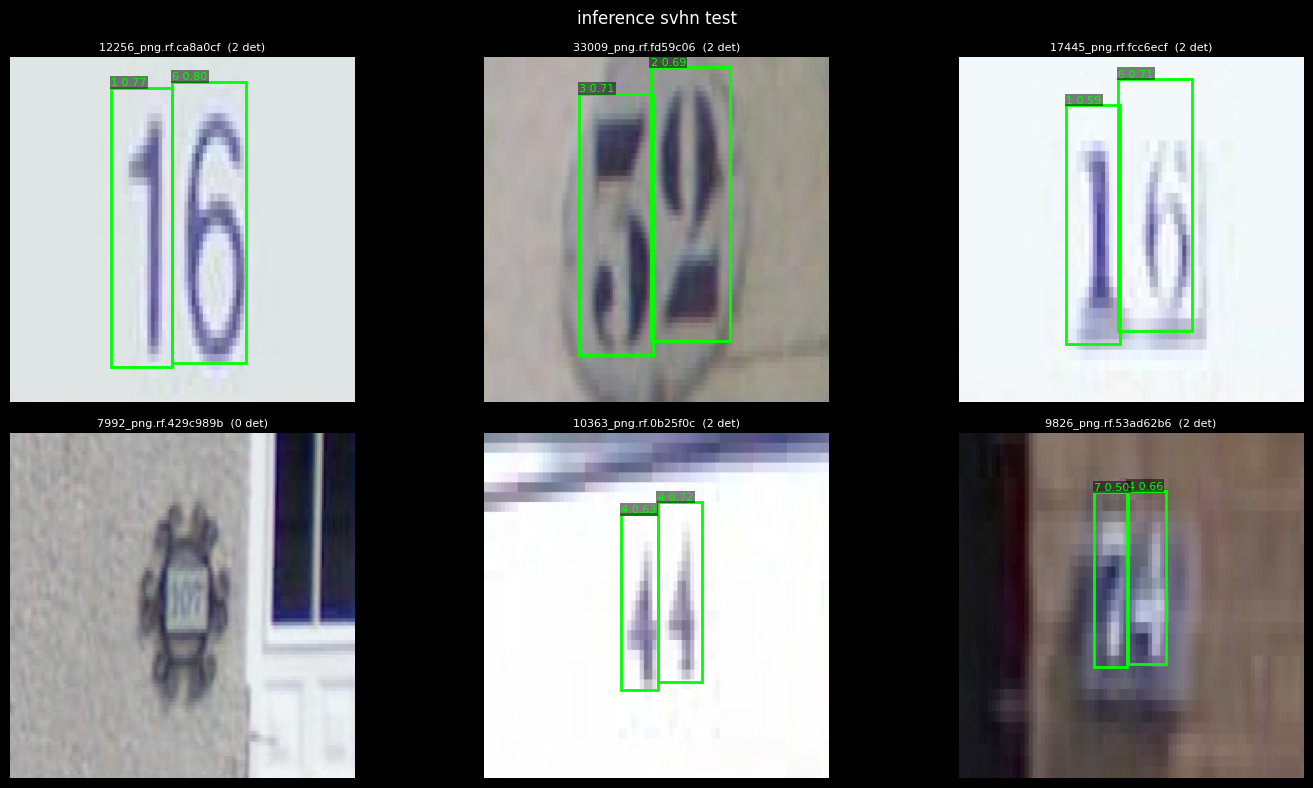

-> /Users/zji25/PycharmProjects/comp-vision/lab2/output/inference_svhn_test.png


In [24]:
show_inference(model_final, SVHN_DIR / "test" / "images", SVHN_CLASSES, conf=0.25, imgsz=416, title="inference svhn test", n=6)

training curves

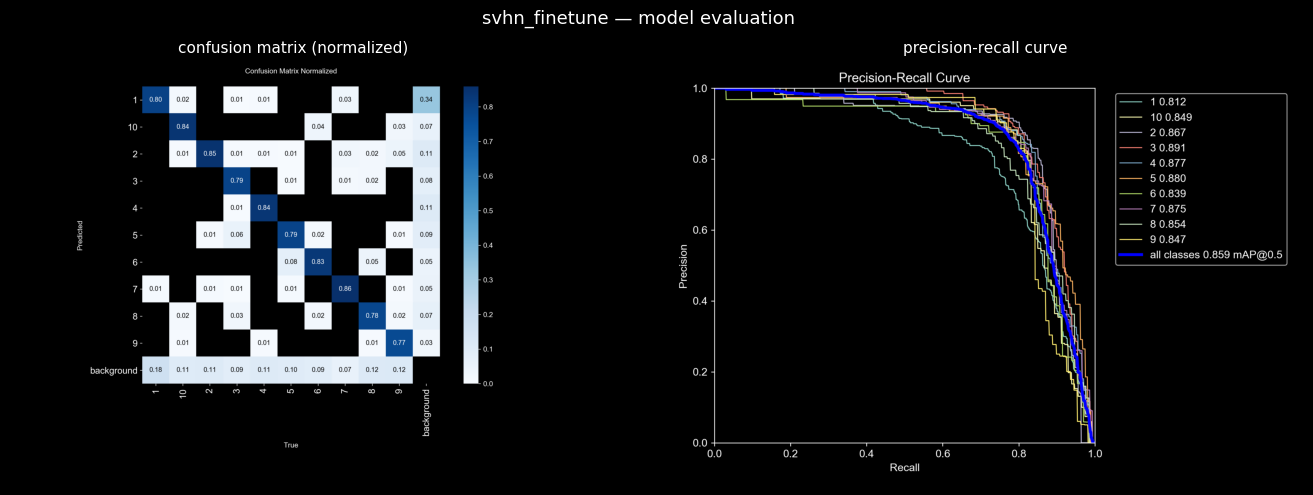

-> /Users/zji25/PycharmProjects/comp-vision/lab2/output/eval_plots.png


In [28]:
run_dir = OUT_DIR / "runs" / "svhn_finetune"
plots = [(run_dir / "confusion_matrix_normalized.png", "confusion matrix (normalized)"), (run_dir / "BoxPR_curve.png", "precision-recall curve")]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (path, title) in zip(axes, plots):
    ax.imshow(Image.open(path))
    ax.set_title(title, fontsize=11)
    ax.axis("off")
fig.suptitle("svhn_finetune — model evaluation", fontsize=13)
fig.tight_layout()
out = OUT_DIR / "eval_plots.png"
fig.savefig(out, dpi=120)
plt.show()
print(f"-> {out}")

results summary

In [29]:
summary = {
    "eval_dataset": "svhn_test",
    "mAP50": round(map50, 4),
    "mAP50_95": round(map5095, 4),
    "precision": round(prec, 4),
    "recall": round(rec, 4),
    "mean_iou": round(iou_metrics["mean_iou"], 4),
    "precision_iou": round(iou_metrics["precision"], 4),
    "recall_iou": round(iou_metrics["recall"], 4),
    "tp": iou_metrics.get("tp", 0),
    "fp": iou_metrics.get("fp", 0),
    "fn": iou_metrics.get("fn", 0),
    "target_map50_achieved": bool(map50 >= 0.60),
}
for k, v in summary.items():
    print(f"  {k:<28} {v}")
if not SUMMARY_PATH.exists():
    with open(SUMMARY_PATH, "w") as f:
        json.dump(summary, f, indent=2)
    print(f"-> {SUMMARY_PATH}")
else:
    print(f"summary.json already exists, not overwriting")

  eval_dataset                 svhn_test
  mAP50                        0.7701
  mAP50_95                     0.3475
  precision                    0.8518
  recall                       0.7812
  mean_iou                     0.7312
  precision_iou                0.8167
  recall_iou                   0.8325
  tp                           1123
  fp                           252
  fn                           226
  target_map50_achieved        True
summary.json already exists, not overwriting


## вывод

обучили yolov11n на детекцию цифр, классы 0–9, в два этапа

1. предобучение на numberdetection, 1032 изображения, 50 эпох, imgsz=640
numberdetection содержит цифры на тёмном фоне: табло, счётчики. домен отличается от svhn, но даёт модели начальное понимание форм цифр

2. дообучение на svhn, примерно 6300 изображений это fraction=0.3 от 21093, 20 эпох, imgsz=416
обучение поверх весов первого этапа сходится быстрее чем с нуля. меньший imgsz и fraction сокращают время без особой потери качества

метрики на тестовой части svhn, 641 изображение, iou_thresh=0.5:

| метрика | значение |
|---|---|
| mAP@50 | 0.770 (цель 0.6) |
| mAP@50-95 | 0.348 |
| Precision (val) | 0.852 |
| Recall (val) | 0.781 |
| mean IoU | 0.731 |
| Precision (IoU) | 0.817 |
| Recall (IoU) | 0.833 |
| TP / FP / FN | 1123 / 252 / 226 |

по матрице ошибок хуже всего идёт цифра 1, 0.80 по диагонали и 0.34 уходит в background: скорее всего из-за узкой формы. лучше всего 7 и 2. mAP@50-95 заметно ниже mAP@50: модель находит объекты но точность рамок при строгих порогах iou хуже

фото номерных знаков

модель плохо сработала на собственных фото. причина: доменный разрыв. svhn это американские номера домов на стенах и дверях, а на фото тайские автомобильные номера с другим шрифтом, цветом фона и тайскими символами которых в обучающих данных нет вообще